Using device: mps
Using 5 filtered members from softmax_ensemble_analysis_results.json
Loaded symmetric calibration scale: 0.700
Loading cached PPE mean from ppe_train_mean.nc
Preparing sample 259...
Running ensemble inference...


100%|██████████| 5/5 [00:00<00:00,  7.05it/s]



Figure saved to: /Users/ewellmeyer/Documents/research/weights/unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch200_k3_128x_dPbins64_gn1_dpmin-700_dPmax1200/ensemble_maps_sample_259_symcal.png


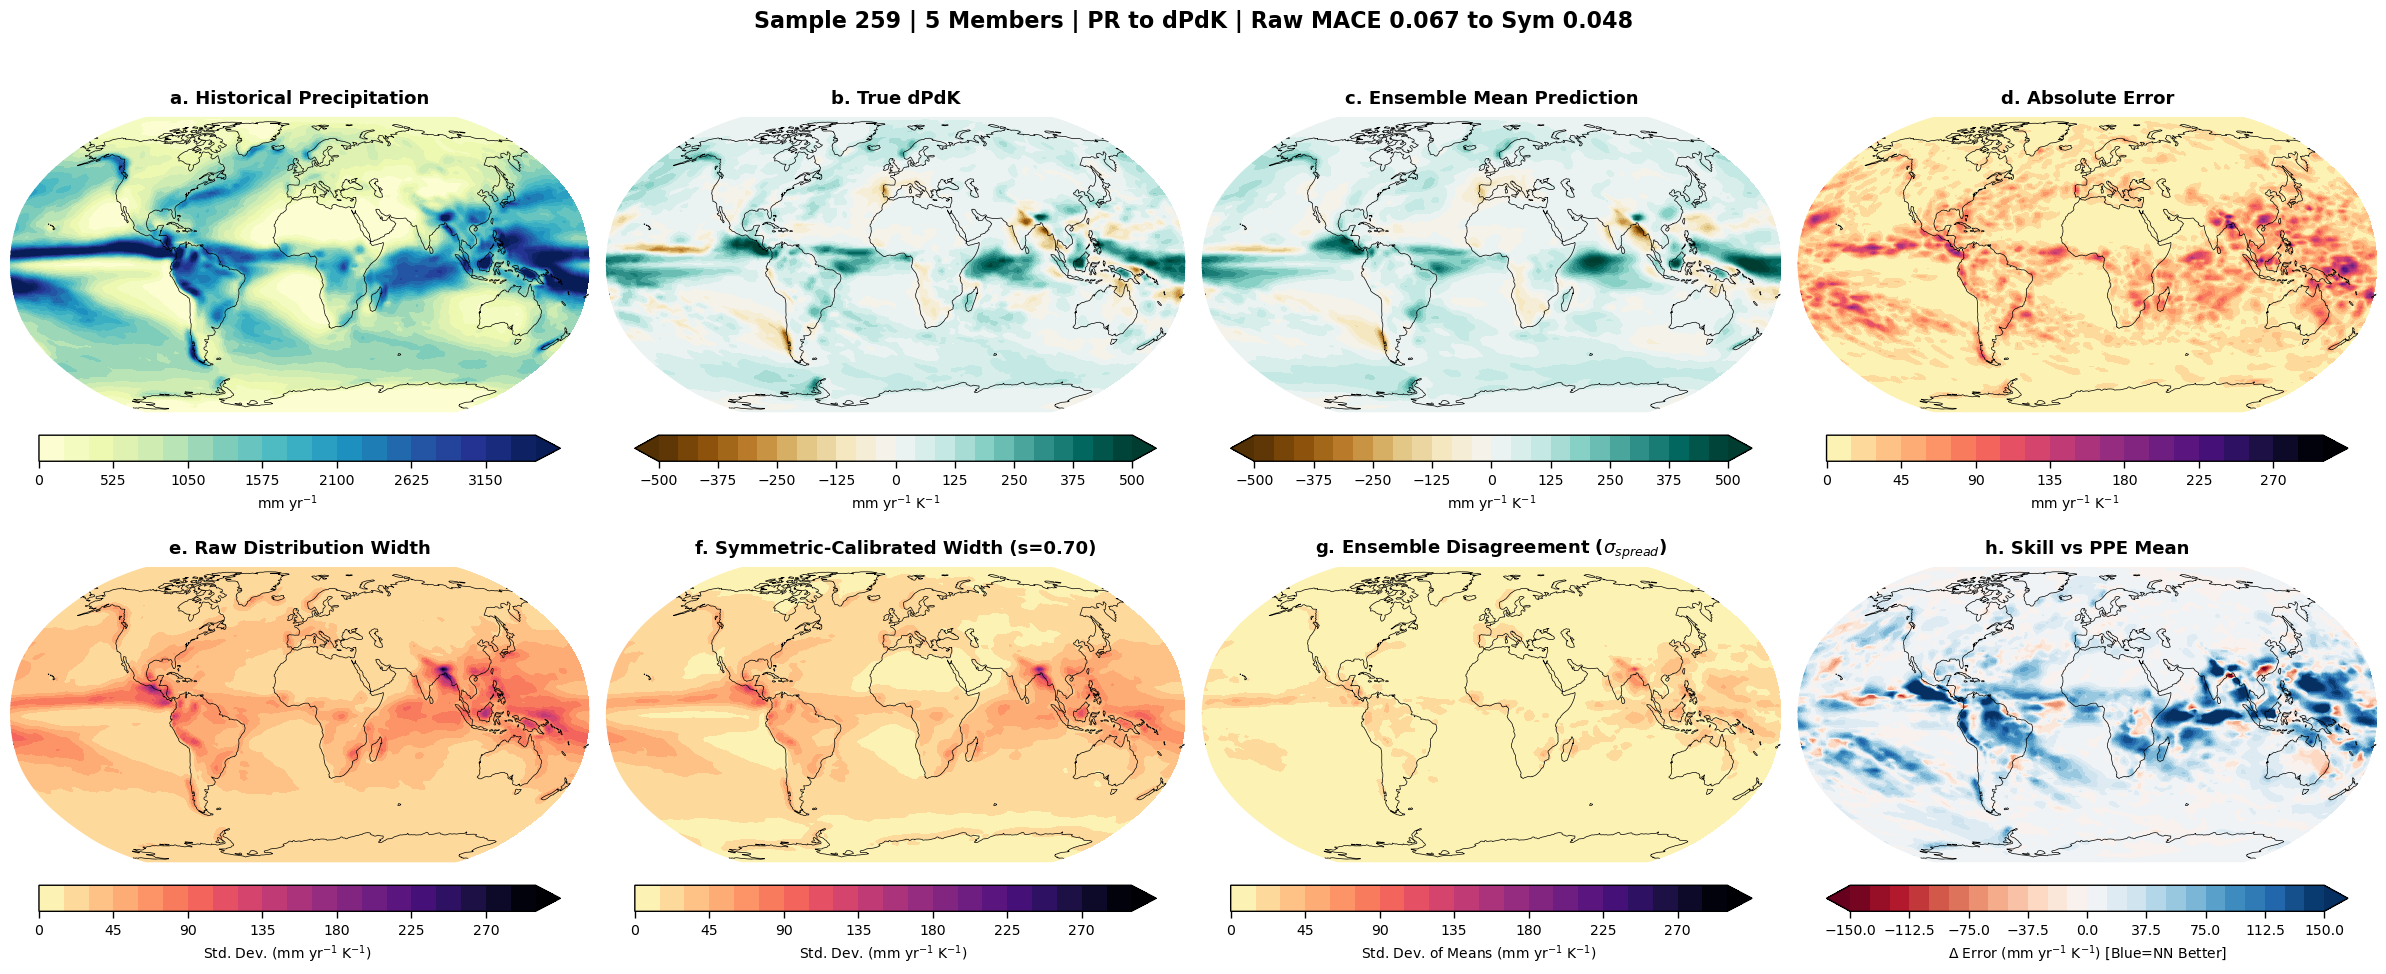


MAP SUMMARY
Members used:                      5
Mean NN error:                     17.55 mm/yr/K
Mean PPE error:                    29.83 mm/yr/K
Relative error reduction:          41.2%
Mean skill (PPE error - NN error): 12.28 mm/yr/K
Median skill:                      3.21 mm/yr/K
NN better than PPE:                68.9% of pixels
Mean raw sigma_total:              32.34 mm/yr/K
Mean calibrated sigma_total:       22.64 mm/yr/K
Mean sigma_spread:                 6.95 mm/yr/K
Symmetric calibration scale:       0.700
Validation symmetric MACE:         0.0464
Test raw MACE:                     0.0667
Test symmetric MACE:               0.0481


In [1]:
import json
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"shapely(\\..*)?",
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"cartopy(\\..*)?",
)

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import xarray as xr
from tqdm import tqdm

from unet import ProbUNet



# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
sample_idx = 259  # absolute realization index in GA789 files

lat_dim = 128
num_bins = 64
base_channels = 200
gn_groups = 1
kernel_size = 3
dP_min = -700
dP_max = 1200

prefer_good_members = True
use_symmetric_calibration = True


# ==============================================================================
# 2. PATHS
# ==============================================================================
base_dir = Path("/Users/ewellmeyer/Documents/research")
data_dir = base_dir / "HadGEM"
weights_dir = base_dir / "weights"

input_file = data_dir / f"GA789_PR_his_rg{lat_dim}.nc"
truth_file = data_dir / f"GA789_dPdK_rg{lat_dim}.nc"

ens_name = (
    f"unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch{base_channels}_k{kernel_size}_"
    f"{lat_dim}x_dPbins{num_bins}_gn{gn_groups}_dpmin{dP_min}_dPmax{dP_max}"
)
ens_dir = weights_dir / ens_name

norm_stats_path = ens_dir / "norm_stats.json"
bin_info_path = ens_dir / "born_bins.json"
splits_path = ens_dir / "data_splits.npz"
analysis_path = ens_dir / "softmax_ensemble_analysis_results.json"
calibration_path = ens_dir / "temperature_calibration.json"

ppe_mean_cache = ens_dir / "ppe_train_mean.nc"
figure_path = ens_dir / f"ensemble_maps_sample_{sample_idx}_symcal.png"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


# ==============================================================================
# 3. HELPERS
# ==============================================================================
def get_member_files():
    member_files = sorted(ens_dir.glob(f"{ens_dir.name}_member*.pth"))
    if not member_files:
        raise RuntimeError(f"No ensemble members found in {ens_dir}")

    if prefer_good_members and analysis_path.exists():
        with open(analysis_path, "r") as f:
            analysis = json.load(f)
        good_members = analysis.get("good_members", [])
        if good_members:
            member_files = [member_files[i] for i in good_members]
            print(f"Using {len(member_files)} filtered members from {analysis_path.name}")
            return member_files

    print(f"Using all {len(member_files)} members")
    return member_files


def get_symmetric_scale():
    if not use_symmetric_calibration:
        print("Symmetric calibration disabled")
        return 1.0, None

    if not calibration_path.exists():
        print("No calibration summary found; using raw uncertainty")
        return 1.0, None

    with open(calibration_path, "r") as f:
        cal = json.load(f)

    sym = cal.get("validation_symmetric_best", {})
    scale = float(sym.get("scale", 1.0))
    print(f"Loaded symmetric calibration scale: {scale:.3f}")
    return scale, cal


def get_ppe_train_mean(train_indices):
    if ppe_mean_cache.exists():
        print(f"Loading cached PPE mean from {ppe_mean_cache.name}")
        with xr.open_dataset(ppe_mean_cache) as ds_mean:
            return ds_mean["dPdK_mean"].values

    print(f"Computing PPE training mean from {len(train_indices)} samples...")
    with xr.open_dataset(truth_file) as ds_truth:
        ppe_mean = ds_truth["dPdK"].isel(realization=train_indices).mean(dim="realization").values
        ds_mean = xr.Dataset(
            {"dPdK_mean": (["latitude", "longitude"], ppe_mean)},
            coords={"latitude": ds_truth.latitude, "longitude": ds_truth.longitude},
        )
        ds_mean.to_netcdf(ppe_mean_cache)

    return ppe_mean


def get_ensemble_metrics(realization_idx, member_files, sym_scale):
    print(f"Preparing sample {realization_idx}...")

    with open(norm_stats_path, "r") as f:
        ns = json.load(f)
    x_mean = np.array(ns["x_mean"], dtype=np.float32).reshape(1, 1, 1, 1)
    x_std = np.array(ns["x_std"], dtype=np.float32).reshape(1, 1, 1, 1)
    y_mean = float(ns["y_mean"])
    y_std = float(ns["y_std"])

    with open(bin_info_path, "r") as f:
        bi = json.load(f)
    bin_centers = np.array(bi["bin_centers_norm"], dtype=np.float32)
    bin_centers_t = torch.tensor(bin_centers, dtype=torch.float32, device=device).view(1, -1, 1, 1)

    with xr.open_dataset(input_file) as ds_in, xr.open_dataset(truth_file) as ds_truth:
        ds_in_one = ds_in.isel(realization=realization_idx)
        ds_truth_one = ds_truth.isel(realization=realization_idx)
        lats = ds_in_one.latitude.values
        lons = ds_in_one.longitude.values
        x_pr = ds_in_one["PR"].values[np.newaxis, np.newaxis, ...]
        y_true = ds_truth_one["dPdK"].values

    x_norm = (x_pr - x_mean) / x_std
    x_in = torch.tensor(x_norm, dtype=torch.float32, device=device)

    model = ProbUNet(1, base_channels, kernel_size, 0.0, num_bins, gn_groups=gn_groups).to(device)
    accum_probs = torch.zeros((1, num_bins, len(lats), len(lons)), dtype=torch.float32, device=device)
    accum_mu = torch.zeros((1, 1, len(lats), len(lons)), dtype=torch.float32, device=device)
    accum_mu_sq = torch.zeros((1, 1, len(lats), len(lons)), dtype=torch.float32, device=device)

    print("Running ensemble inference...")
    with torch.inference_mode():
        for member_file in tqdm(member_files):
            ckpt = torch.load(member_file, map_location=device)
            state = ckpt["model"] if "model" in ckpt else ckpt
            model.load_state_dict(state, strict=False)
            model.eval()

            probs = model.forward_components(x_in).float()
            accum_probs += probs

            mu_mem_norm = (probs * bin_centers_t).sum(dim=1, keepdim=True)
            accum_mu += mu_mem_norm
            accum_mu_sq += mu_mem_norm ** 2

    n_members = len(member_files)
    avg_probs = accum_probs / n_members

    mu_total_norm = (avg_probs * bin_centers_t).sum(dim=1)
    var_total_raw_norm = (avg_probs * (bin_centers_t - mu_total_norm.unsqueeze(1)) ** 2).sum(dim=1)
    sigma_total_raw_norm = torch.sqrt(torch.clamp(var_total_raw_norm, min=0.0))
    sigma_total_cal_norm = sigma_total_raw_norm * np.float32(sym_scale)

    mean_of_means = accum_mu / n_members
    mean_of_sqs = accum_mu_sq / n_members
    var_spread_norm = torch.clamp(mean_of_sqs - (mean_of_means ** 2), min=0.0)
    sigma_spread_norm = torch.sqrt(var_spread_norm).squeeze(1)

    pred_mm = mu_total_norm.cpu().numpy().squeeze() * y_std + y_mean
    sigma_total_raw_mm = sigma_total_raw_norm.cpu().numpy().squeeze() * y_std
    sigma_total_cal_mm = sigma_total_cal_norm.cpu().numpy().squeeze() * y_std
    sigma_spread_mm = sigma_spread_norm.cpu().numpy().squeeze() * y_std

    return {
        "lats": lats,
        "lons": lons,
        "x_pr": x_pr.squeeze(),
        "y_true": y_true.squeeze(),
        "pred": pred_mm,
        "sigma_total_raw": sigma_total_raw_mm,
        "sigma_total_cal": sigma_total_cal_mm,
        "sigma_spread": sigma_spread_mm,
    }


def format_ax(ax, title):
    ax.coastlines(linewidth=0.5, color="black")
    ax.set_title(title, fontsize=13, pad=10, fontweight="bold")
    ax.axis("off")


# ==============================================================================
# 4. RUN
# ==============================================================================
if not splits_path.exists():
    raise FileNotFoundError(f"Split file not found: {splits_path}")
if sample_idx < 0:
    raise ValueError("sample_idx must be non-negative")

splits = np.load(splits_path)
train_indices = splits["train"].tolist()

member_files = get_member_files()
sym_scale, cal_summary = get_symmetric_scale()
ppe_train_mean = get_ppe_train_mean(train_indices)

results = get_ensemble_metrics(sample_idx, member_files, sym_scale)
lats = results["lats"]
lons = results["lons"]
p_hist = results["x_pr"]
dP_target = results["y_true"]
dP_pred = results["pred"]
sigma_total_raw = results["sigma_total_raw"]
sigma_total_cal = results["sigma_total_cal"]
sigma_spread = results["sigma_spread"]

nn_error = np.abs(dP_pred - dP_target)
ppe_error = np.abs(ppe_train_mean - dP_target)
skill_map = ppe_error - nn_error

sns.set_context("paper", font_scale=1.15)
fig = plt.figure(figsize=(24, 10))

proj = ccrs.Robinson(central_longitude=0)
trans = ccrs.PlateCarree()

ax1 = plt.subplot(2, 4, 1, projection=proj)
im1 = ax1.contourf(lons, lats, p_hist, transform=trans, levels=np.linspace(0, 3500, 21), cmap="YlGnBu", extend="max")
format_ax(ax1, "a. Historical Precipitation")
cb1 = plt.colorbar(im1, ax=ax1, orientation="horizontal", pad=0.05, shrink=0.9)
cb1.set_label(r"mm yr$^{-1}$", fontsize=10)

ax2 = plt.subplot(2, 4, 2, projection=proj)
im2 = ax2.contourf(lons, lats, dP_target, transform=trans, levels=np.linspace(-500, 500, 25), cmap="BrBG", extend="both")
format_ax(ax2, "b. True dPdK")
cb2 = plt.colorbar(im2, ax=ax2, orientation="horizontal", pad=0.05, shrink=0.9)
cb2.set_label(r"mm yr$^{-1}$ K$^{-1}$", fontsize=10)

ax3 = plt.subplot(2, 4, 3, projection=proj)
im3 = ax3.contourf(lons, lats, dP_pred, transform=trans, levels=np.linspace(-500, 500, 25), cmap="BrBG", extend="both")
format_ax(ax3, "c. Ensemble Mean Prediction")
cb3 = plt.colorbar(im3, ax=ax3, orientation="horizontal", pad=0.05, shrink=0.9)
cb3.set_label(r"mm yr$^{-1}$ K$^{-1}$", fontsize=10)

ax4 = plt.subplot(2, 4, 4, projection=proj)
im4 = ax4.contourf(lons, lats, nn_error, transform=trans, levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(ax4, "d. Absolute Error")
cb4 = plt.colorbar(im4, ax=ax4, orientation="horizontal", pad=0.05, shrink=0.9)
cb4.set_label(r"mm yr$^{-1}$ K$^{-1}$", fontsize=10)

ax5 = plt.subplot(2, 4, 5, projection=proj)
im5 = ax5.contourf(lons, lats, sigma_total_raw, transform=trans, levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(ax5, "e. Raw Distribution Width")
cb5 = plt.colorbar(im5, ax=ax5, orientation="horizontal", pad=0.05, shrink=0.9)
cb5.set_label(r"Std. Dev. (mm yr$^{-1}$ K$^{-1}$)", fontsize=10)

ax6 = plt.subplot(2, 4, 6, projection=proj)
im6 = ax6.contourf(lons, lats, sigma_total_cal, transform=trans, levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(ax6, f"f. Symmetric-Calibrated Width (s={sym_scale:.2f})")
cb6 = plt.colorbar(im6, ax=ax6, orientation="horizontal", pad=0.05, shrink=0.9)
cb6.set_label(r"Std. Dev. (mm yr$^{-1}$ K$^{-1}$)", fontsize=10)

ax7 = plt.subplot(2, 4, 7, projection=proj)
im7 = ax7.contourf(lons, lats, sigma_spread, transform=trans, levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(ax7, r"g. Ensemble Disagreement ($\sigma_{spread}$)")
cb7 = plt.colorbar(im7, ax=ax7, orientation="horizontal", pad=0.05, shrink=0.9)
cb7.set_label(r"Std. Dev. of Means (mm yr$^{-1}$ K$^{-1}$)", fontsize=10)

ax8 = plt.subplot(2, 4, 8, projection=proj)
skill_levels = np.linspace(-150, 150, 25)
im8 = ax8.contourf(lons, lats, skill_map, transform=trans, levels=skill_levels, cmap="RdBu", extend="both")
format_ax(ax8, "h. Skill vs PPE Mean")
cb8 = plt.colorbar(im8, ax=ax8, orientation="horizontal", pad=0.05, shrink=0.9)
cb8.set_label(r"$\Delta$ Error (mm yr$^{-1}$ K$^{-1}$) [Blue=NN Better]", fontsize=10)

title = f"Sample {sample_idx} | {len(member_files)} Members | PR to dPdK"
if cal_summary is not None:
    raw_mace = cal_summary.get("test_raw", {}).get("mace")
    sym_mace = cal_summary.get("test_symmetric", {}).get("mace")
    if raw_mace is not None and sym_mace is not None:
        title += f" | Raw MACE {raw_mace:.3f} to Sym {sym_mace:.3f}"
plt.suptitle(title, fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
print(f"\nFigure saved to: {figure_path}")
plt.show()

skill_mean = float(np.mean(skill_map))
skill_median = float(np.median(skill_map))
pct_better = float((skill_map > 0).sum() / skill_map.size * 100.0)

print("\n" + "=" * 60)
print("MAP SUMMARY")
print("=" * 60)
print(f"Members used:                      {len(member_files)}")
print(f"Mean NN error:                     {np.mean(nn_error):.2f} mm/yr/K")
print(f"Mean PPE error:                    {np.mean(ppe_error):.2f} mm/yr/K")
print(f"Relative error reduction:          {(1 - np.mean(nn_error) / np.mean(ppe_error)) * 100:.1f}%")
print(f"Mean skill (PPE error - NN error): {skill_mean:.2f} mm/yr/K")
print(f"Median skill:                      {skill_median:.2f} mm/yr/K")
print(f"NN better than PPE:                {pct_better:.1f}% of pixels")
print(f"Mean raw sigma_total:              {np.mean(sigma_total_raw):.2f} mm/yr/K")
print(f"Mean calibrated sigma_total:       {np.mean(sigma_total_cal):.2f} mm/yr/K")
print(f"Mean sigma_spread:                 {np.mean(sigma_spread):.2f} mm/yr/K")
if cal_summary is not None:
    print(f"Symmetric calibration scale:       {sym_scale:.3f}")
    print(f"Validation symmetric MACE:         {cal_summary['validation_symmetric_best']['mace']:.4f}")
    print(f"Test raw MACE:                     {cal_summary['test_raw']['mace']:.4f}")
    print(f"Test symmetric MACE:               {cal_summary['test_symmetric']['mace']:.4f}")
print("=" * 60)
